In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import chess
import chess.svg
import random
import time
import math
import csv
from tqdm import tqdm
from pathlib import Path
from IPython.display import display, SVG

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 512
MODEL_DIR = Path("models")
LOGS_DIR = Path("experiments/logs")
DATASET_READY_DIR = Path("./dataset_ready/train/train_balanced.parquet")

In [11]:
# ==========================================
# Configuration
# ==========================================
class Config:
    """
    Things to change: Active probes, F1 weight, both model save name
    Knight 10
    Bishop 10
    Rook 6
    Queen 4

    print(chess.PAWN, chess.KNIGHT, chess.BISHOP, chess.ROOK, chess.QUEEN, chess.KING)
    result: 1 2 3 4 5 6
    """
    # Models to train in this run
    # ACTIVE_PROBES = ["TRANSFORMER_8H", "TRANSFORMER_4H", "CNN", "MLP"]
    ACTIVE_PROBES = ["CNN"]
    PROBE_PIECE_TYPE = chess.KNIGHT
    
    # Training Hyperparameters
    EPOCHS = 10
    LEARNING_RATE = 1e-3
    
    # Inference / Visualization Settings
    TEST_FEN = "1r3r2/2p1qpk1/p2p3p/1p4p1/4P3/3QN1bP/P2K2P1/1R3B2 w - - 0 1"
    TARGET_SQUARE = chess.parse_square("e3") # Set to None for a random piece

MODEL_REGISTRY = {
    "CNN": {
        "name": "seresnet_new_v2_16",
        "dataset_dir": Path("./dataset_planes_cp/"),
        "is_3d": True,
        "model_kwargs": {"in_channels": 19, "channels": 64, "num_blocks": 16, "num_classes": 7}
    },
    "MLP": {
        "name": "probs_mlp_v4",
        "dataset_dir": Path("./dataset_bitmaps_cp/"),
        "is_3d": False,
        "model_kwargs": {"input_shape": 775, "output_shape": 7}
    },
    "TRANSFORMER_4H": {
        "name": "transformer_v1",
        "dataset_dir": Path("./dataset_planes_cp/"),
        "is_3d": True,
        "model_kwargs": {"input_channels": 19, "embed_dim": 128, "num_heads": 4, "ffn_dim": 512, "num_blocks": 6, "num_classes": 7}
    },
    "TRANSFORMER_8H": {
        "name": "transformer_v2",
        "dataset_dir": Path("./dataset_planes_cp/"), 
        "is_3d": True,
        "model_kwargs": {"input_channels": 19, "embed_dim": 256, "num_heads": 8, "ffn_dim": 512, "num_blocks": 6, "num_classes": 7}
    }
}

In [12]:
# ==========================================
# Architectures
# ==========================================
# --- MLP ---
class MLP(nn.Module):
    def __init__(self, input_shape=775, output_shape=7):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_shape, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, output_shape)
        )
    def forward(self, x): return self.network(x)

# --- CNN ---
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction), nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels), nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.mlp(self.avg_pool(x).view(b, c)).view(b, c, 1, 1)
        return x * y.expand_as(x)

class DropPath(nn.Module):
    def __init__(self, drop_prob: float = 0.):
        super().__init__()
        self.drop_prob = drop_prob
    def forward(self, x):
        if self.drop_prob == 0. or not self.training: return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = x.new_empty(shape).bernoulli_(keep_prob)
        return x.div(keep_prob) * random_tensor

class ResidualBlock(nn.Module):
    def __init__(self, channels, drop_prob=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1, self.bn2 = nn.BatchNorm2d(channels), nn.BatchNorm2d(channels)
        self.relu, self.se = nn.ReLU(), SEBlock(channels, reduction=8)
        self.drop_path = DropPath(drop_prob) if drop_prob > 0. else nn.Identity()
    def forward(self, x):
        identity = x 
        x = self.se(self.bn2(self.conv2(self.relu(self.bn1(self.conv1(x))))))
        return self.relu(self.drop_path(x) + identity)

class SEResNet(nn.Module):
    def __init__(self, in_channels=19, channels=64, num_blocks=16, num_classes=7, drop_path_rate=0.0):
        super().__init__()
        self.initialconv = nn.Sequential(
            nn.Conv2d(in_channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels), nn.ReLU()
        )
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, num_blocks)]
        self.res_tower = nn.Sequential(*[ResidualBlock(channels, drop_prob=dpr[i]) for i in range(num_blocks)])
        self.bottleneck = nn.Sequential(
            nn.Conv2d(channels, 32, kernel_size=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.Linear(32, 256), nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.bottleneck(self.res_tower(self.initialconv(x))))

# --- TRANSFORMER ---
class Ffn(nn.Module):
    def __init__(self, embed_dim, ffn_dim):
        super().__init__()
        self.linear1 = nn.Linear(embed_dim, ffn_dim)
        self.activation = nn.ReLU() 
        self.linear2 = nn.Linear(ffn_dim, embed_dim)
    def forward(self, x):
        return self.linear2(self.activation(self.linear1(x)))

class EncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ffn_dim, num_blocks):
        super().__init__()
        self.alpha = math.pow(2.0 * num_blocks, -0.25)
        self.mha = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.ln1, self.ln2 = nn.LayerNorm(embed_dim), nn.LayerNorm(embed_dim)
        self.ffn = Ffn(embed_dim, ffn_dim)
    def forward(self, x):
        attn_out, _ = self.mha(x, x, x, need_weights=True, average_attn_weights=False)
        x = x + attn_out * self.alpha
        identity = self.ln1(x)
        x = identity + self.ffn(identity) * self.alpha
        return self.ln2(x)

class Transformer(nn.Module):
    def __init__(self, input_channels=19, embed_dim=128, num_heads=4, ffn_dim=512, num_blocks=6, num_classes=7):
        super().__init__()
        self.embedding = nn.Linear(input_channels, embed_dim)
        self.embed_activation = nn.ReLU()
        self.embed_norm = nn.LayerNorm(embed_dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, 64, embed_dim))
        nn.init.normal_(self.pos_embedding, mean=0, std=0.02)
        
        self.blocks = nn.ModuleList([EncoderBlock(embed_dim, num_heads, ffn_dim, num_blocks) for _ in range(num_blocks)])
        self.classifier_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2), nn.ReLU(), nn.Linear(embed_dim // 2, num_classes)
        )
    def forward(self, x):
        x = x.permute(0, 2, 3, 1).flatten(1, 2)
        x = self.embed_norm(self.embed_activation(self.embedding(x))) + self.pos_embedding
        for block in self.blocks: x = block(x)
        return self.classifier_head(x.mean(dim=1))

In [13]:
# ==========================================
# Utility Functions
# ==========================================
def fen_to_tensor(fen):
    board = chess.Board(fen)
    tensor = np.zeros((19, 8, 8), dtype=np.float32)
    piece_to_channel = {"P":0, "N":1, "B":2, "R":3, "Q":4, "K":5, "p":6, "n":7, "b":8, "r":9, "q":10, "k":11}
    for square, piece in board.piece_map().items():
        row, col = divmod(square, 8)
        tensor[piece_to_channel[piece.symbol()], row, col] = 1
    
    if board.turn == chess.WHITE: tensor[12, :, :] = 1
    if board.has_kingside_castling_rights(chess.WHITE): tensor[13, :, :] = 1
    if board.has_queenside_castling_rights(chess.WHITE): tensor[14, :, :] = 1
    if board.has_kingside_castling_rights(chess.BLACK): tensor[15, :, :] = 1
    if board.has_queenside_castling_rights(chess.BLACK): tensor[16, :, :] = 1
    if board.is_check(): tensor[17, :, :] = 1
    if board.ep_square is not None:
        row, col = divmod(board.ep_square, 8)
        tensor[18, row, col] = 1
    return tensor

def fen_to_vector(fen):
    board = chess.Board(fen)
    vector = np.zeros(775, dtype=np.float32)
    piece_to_idx = {"P":0, "N":1, "B":2, "R":3, "Q":4, "K":5, "p":6, "n":7, "b":8, "r":9, "q":10, "k":11}
    for square, piece in board.piece_map().items():
        vector[piece_to_idx[piece.symbol()] * 64 + square] = 1
        
    if board.turn == chess.WHITE: vector[768] = 1
    if board.has_kingside_castling_rights(chess.WHITE): vector[769] = 1
    if board.has_queenside_castling_rights(chess.WHITE): vector[770] = 1
    if board.has_kingside_castling_rights(chess.BLACK): vector[771] = 1
    if board.has_queenside_castling_rights(chess.BLACK): vector[772] = 1
    return vector

def render_heatmap_svg(saliency_64, fen_str, title, display_svg=True):
    sal_min, sal_max = np.min(saliency_64), np.max(saliency_64)
    if sal_max > sal_min:
        saliency_norm = (saliency_64 - sal_min) / (sal_max - sal_min)
    else:
        saliency_norm = saliency_64

    cmap = plt.get_cmap("viridis")
    fill_dict = {i: mcolors.to_hex(cmap(saliency_norm[i]), keep_alpha=False) for i in range(64)}
    
    for square_idx in range(64):
        val = saliency_norm[square_idx]
        rgba = cmap(val)
        hex_color = mcolors.to_hex(rgba, keep_alpha=False)
        fill_dict[square_idx] = hex_color

    board_svg = chess.svg.board(
        chess.Board(fen_str),
        fill=fill_dict,
        size=350,
        coordinates=False,
        style=".square { stroke: white; stroke-width: 1.5px; }"
    )
    
    if display_svg:
        print(title)
        display(SVG(board_svg))

    return board_svg

def load_model(setup, model_key: str):
    if "CNN" in model_key:
        model = SEResNet(**setup["model_kwargs"]).to(DEVICE)
        return model
    elif "MLP" in model_key:
        model = MLP(**setup["model_kwargs"]).to(DEVICE)
        return model
    elif model_key in ["TRANSFORMER", "TRANSFORMER_4H", "TRANSFORMER_4H_PROBE", "TRANSFORMER_8H"]:
        model = Transformer(**setup["model_kwargs"]).to(DEVICE)
        return model

In [ ]:
# ==========================================
# Probing Dataset & Architecture
# ==========================================
class LegalMoveProbeDataset(Dataset):
    def __init__(self, npy_dir: Path, parquet_path: Path, split: str):
        self.npy_dir = Path(npy_dir)
        self.X = np.load(self.npy_dir / f"{split}_X.npy", mmap_mode='r')
        
        df = pd.read_parquet(parquet_path, columns=['fen'])
        self.fens = df['fen'].values
        assert len(self.X) == len(self.fens), f"Mismatch: {len(self.X)} tensors vs {len(self.fens)} FENs"

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx):
        x_tensor = torch.tensor(self.X[idx], dtype=torch.float32)
        fen = str(self.fens[idx])
        board = chess.Board(fen)
        
        pieces = []
        for piece_type in [Config.PROBE_PIECE_TYPE]:
            pieces.extend(list(board.pieces(piece_type, board.turn))) # collects all squares of pieces belonging to the side to move
            
        if not pieces:
            return x_tensor, torch.zeros(64, dtype=torch.float32), torch.zeros(64, dtype=torch.float32)
        
        target_square = random.choice(pieces)
        
        # one hot encoding of the square that contains the piece
        piece_loc_mask = np.zeros(64, dtype=np.float32)
        piece_loc_mask[target_square] = 1.0
        
        # one hot encodes all possible moves from the original square that contains piece
        legal_move_mask = np.zeros(64, dtype=np.float32)
        for move in board.legal_moves:
            if move.from_square == target_square:
                legal_move_mask[move.to_square] = 1.0
                
        return x_tensor, torch.tensor(piece_loc_mask), torch.tensor(legal_move_mask)
    
class LatentExtractor:
    def __init__(self, model, model_key):
        self.model = model.eval() 
        self.latent = None
        self.model_key = model_key
        self.handle = self._register_hook()

    def _register_hook(self):
        def hook_fn(module, input, output):
            # We grab the OUTPUT of these rich spatial layers!
            self.latent = output.detach()

        # CNN: Hook the bottleneck right before AdaptiveAvgPool2d (Output: [B, 32, 8, 8])
        if "CNN" in self.model_key:
            return self.model.bottleneck.register_forward_hook(hook_fn)
            
        # TRANSFORMER: Hook the final Encoder block right before x.mean() (Output: [B, 64, Embed_Dim])
        elif self.model_key in ["TRANSFORMER", "TRANSFORMER_4H", "TRANSFORMER_4H_PROBE", "TRANSFORMER_8H"]:
            return self.model.blocks[-1].register_forward_hook(hook_fn)
            
        # MLP: Hook the middle of the network before it bottlenecks too hard
        elif "MLP" in self.model_key:
            return self.model.network[7].register_forward_hook(hook_fn) 
            
        else:
            raise ValueError(f"Unknown model_key: {self.model_key}")

    def extract(self, x):
        with torch.no_grad():
            self.model(x)
        return self.latent
        
    def remove_hook(self):
        self.handle.remove()
        
class LegalMoveProbe(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.probe = nn.Linear(latent_dim + 64, 64)
        
    def forward(self, latent, query_one_hot):
        combined = torch.cat([latent, query_one_hot], dim=1)
        return self.probe(combined)

def train_probe_loop(base_model, model_key, probe, dataloader, epochs=10, lr=1e-3):
    print(f"Starting Probe Training on {DEVICE.upper()}...")
    base_model.eval()
    extractor = LatentExtractor(base_model, model_key)
    

    weight = torch.tensor([10.0], device=DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=weight)
    optimizer = torch.optim.AdamW(params=probe.parameters(), lr=lr, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    scaler = torch.amp.GradScaler(device=DEVICE)
    history = []
    
    for epoch in range(epochs):
        probe.train()
        total_loss, total_f1 = 0.0, 0.0

        loop = tqdm(dataloader, desc=f"Epoch [{epoch+1:02d}/{epochs}]", leave=True)

        for batch, (x_tensor, piece_loc_mask, legal_move_mask) in enumerate(loop):
            x_tensor, piece_loc_mask, legal_move_mask = x_tensor.to(DEVICE), piece_loc_mask.to(DEVICE), legal_move_mask.to(DEVICE)
            
            latent = extractor.extract(x_tensor)
            if latent.dim() > 2:
                latent = latent.flatten(1)
                
            optimizer.zero_grad()
            
            with torch.amp.autocast(DEVICE):
                predicted_moves_mask = probe(latent, piece_loc_mask) 
                loss = loss_fn(predicted_moves_mask, legal_move_mask)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            total_loss += loss.item()
            
            with torch.no_grad():
                binary_preds_mask = (torch.sigmoid(predicted_moves_mask) > 0.5).float()
                tp = (binary_preds_mask * legal_move_mask).sum()
                fp = (binary_preds_mask * (1.0 - legal_move_mask)).sum()
                fn = ((1.0 - binary_preds_mask) * legal_move_mask).sum()
                f1 = (2 * tp) / (2 * tp + fp + fn + 1e-8)
                total_f1 += f1.item()
            
            loop.set_postfix(loss=loss.item(), f1=f"{f1.item()*100:.2f}%")

        avg_loss = total_loss / len(dataloader)
        avg_f1 = total_f1 / len(dataloader) 
        history.append(avg_loss)
        
        current_lr = scheduler.get_last_lr()[0]
        scheduler.step()

        print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Loss: {avg_loss:.4f} | F1: {avg_f1*100:.2f}% | LR: {current_lr:.2e}\n")
        
    extractor.remove_hook()
    return history, avg_f1


Processing Probe for: CNN
[CNN] Detected Latent Dimension Size: 2048
[CNN] No existing probe found. Starting training...
Starting Probe Training on CUDA...


Epoch [01/10]: 100%|██████████| 8999/8999 [13:25<00:00, 11.17it/s, f1=88.65%, loss=0.0633]


Epoch [01/10] | Train Loss: 0.2033 | F1: 80.12% | LR: 1.00e-03



Epoch [02/10]: 100%|██████████| 8999/8999 [13:12<00:00, 11.36it/s, f1=83.58%, loss=0.0491]


Epoch [02/10] | Train Loss: 0.0563 | F1: 88.64% | LR: 9.76e-04



...

Epoch [08/10] | Train Loss: 0.0398 | F1: 90.14% | LR: 2.07e-04



Epoch [09/10]: 100%|██████████| 8999/8999 [13:32<00:00, 11.07it/s, f1=90.20%, loss=0.0329]


Epoch [09/10] | Train Loss: 0.0396 | F1: 90.16% | LR: 9.64e-05



Epoch [10/10]: 100%|██████████| 8999/8999 [13:15<00:00, 11.31it/s, f1=86.41%, loss=0.0334]

Epoch [10/10] | Train Loss: 0.0396 | F1: 90.17% | LR: 2.54e-05

[CNN] Saved trained probe to models\seresnet_new_v2_16_2_linear_probe.pth


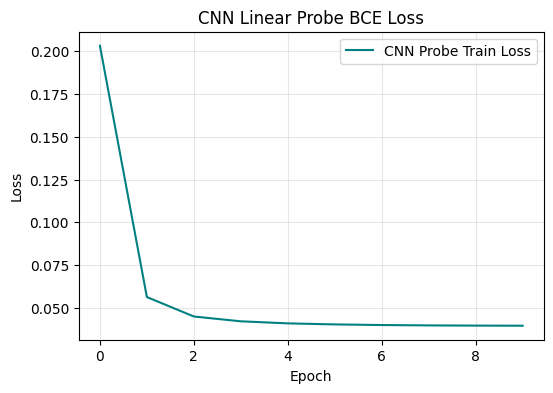

In [ ]:
# ==========================================
# Train or Load Probes
# ==========================================
for model_key in Config.ACTIVE_PROBES:
    setup = MODEL_REGISTRY[model_key]
    print(f"\n{'='*50}\nProcessing Probe for: {model_key}\n{'='*50}")
    model = load_model(setup, model_key)
        
    model_path = MODEL_DIR / f"{setup['name']}.pth"
    try:
        model.load_state_dict(torch.load(model_path))
    except FileNotFoundError:
        print(f"[{model_key}] Base weight file not found at {model_path}. Skipping.")
        continue

    piece_name = chess.piece_name(Config.PROBE_PIECE_TYPE).lower()
    model_log_dir = LOGS_DIR / setup['name']
    model_log_dir.mkdir(parents=True, exist_ok=True) 
    probe_save_path = model_log_dir / f"{setup['name']}_{piece_name}_linear_probe.pth"

    # Dynamically Find Latent Dimension Size
    dummy_shape = (1, 19, 8, 8) if setup['is_3d'] else (1, 775)
    dummy_x = torch.zeros(dummy_shape).to(DEVICE)
    
    dummy_extractor = LatentExtractor(model, model_key)
    dummy_latent = dummy_extractor.extract(dummy_x)
    latent_dim = dummy_latent.flatten(1).shape[1] 
    dummy_extractor.remove_hook()

    print(f"[{model_key}] Detected Latent Dimension Size: {latent_dim}")
    
    # Initialize Probe Model
    probe = LegalMoveProbe(latent_dim=latent_dim).to(DEVICE)

    if probe_save_path.exists():
        print(f"[{model_key}] Found existing probe at {probe_save_path}. Loading weights...")
        probe.load_state_dict(torch.load(probe_save_path))
    else:
        print(f"[{model_key}] No existing probe found. Starting training...")
        
        train_probe_dataset = LegalMoveProbeDataset(
            npy_dir=setup['dataset_dir'], 
            parquet_path=DATASET_READY_DIR, 
            split="train"
        )
        train_probe_dataloader = DataLoader(train_probe_dataset, 
                                            batch_size=BATCH_SIZE, 
                                            shuffle=True, 
                                            pin_memory=True)

        loss_history, f1_score = train_probe_loop(
            base_model=model,
            model_key=model_key,
            probe=probe,
            dataloader=train_probe_dataloader,
            epochs=Config.EPOCHS,
            lr=Config.LEARNING_RATE
        )
        
        torch.save(probe.state_dict(), probe_save_path)
        print(f"[{model_key}] Saved trained probe to {probe_save_path}")

        log_path = model_log_dir / "probe_f1_scores.csv"
        file_exists = log_path.exists()
        
        with open(log_path, mode="a", newline="") as f:
            writer = csv.writer(f)
            if not file_exists:
                writer.writerow(["Model_Key", "Weights_File", "Piece", "Final_F1"]) 
                
            writer.writerow([
                model_key,           
                setup['name'],       
                piece_name.title(), 
                f"{f1_score*100:.2f}%"
            ])
            
        print(f"[{model_key}] Logged Final F1: {f1_score*100:.2f}% to {log_path}")

        plt.figure(figsize=(6, 4))
        plt.plot(loss_history, label=f'{model_key} Probe Train Loss', color='teal')
        plt.title(f"{model_key} Linear Probe BCE Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

Analyzing legal moves for piece at: E3
CNN Probe Predictions (E3)


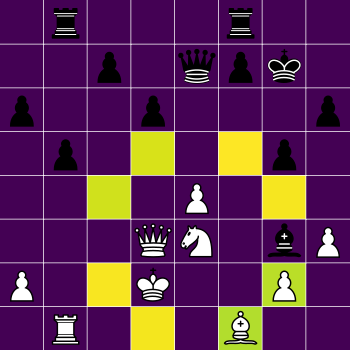

In [16]:
# ==========================================
# Forward Pass & Heatmap Visualization (Standalone)
# ==========================================
board = chess.Board(Config.TEST_FEN)
piece = Config.PROBE_PIECE_TYPE

# Select target piece
if Config.TARGET_SQUARE is not None:
    target_square = Config.TARGET_SQUARE
elif Config.PROBE_PIECE_TYPE is not None:
    # Pick a random piece of the specific type you are probing
    pieces = list(board.pieces(Config.PROBE_PIECE_TYPE, board.turn))
    target_square = random.choice(pieces) if pieces else 0
else:
    # Pick a random piece for the SIDE TO MOVE
    pieces = []
    for piece_type in [chess.PAWN, chess.KNIGHT, chess.BISHOP, chess.ROOK, chess.QUEEN, chess.KING]:
        pieces.extend(list(board.pieces(piece_type, board.turn)))
    target_square = random.choice(pieces) if pieces else 0

piece_name = chess.square_name(target_square)
print(f"Analyzing legal moves for piece at: {piece_name.upper()}")

# Loop through all active probes to generate side-by-side comparisons
for model_key in Config.ACTIVE_PROBES:
    setup = MODEL_REGISTRY[model_key]
    model = load_model(setup, model_key)
        
    model_path = MODEL_DIR / f"{setup['name']}.pth"
    if not model_path.exists():
        print(f"\n[{model_key}] Base model not found at {model_path}. Skipping.")
        continue
        
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    # Setup Extractor & Find Latent Dimension
    extractor = LatentExtractor(model, model_key)
    dummy_shape = (1, 19, 8, 8) if setup['is_3d'] else (1, 775)
    dummy_x = torch.zeros(dummy_shape).to(DEVICE)
    latent_dim = extractor.extract(dummy_x).flatten(1).shape[1]
    
    # Initialize and Load Probe from disk
    probe_save_path = MODEL_DIR / f"{setup['name']}_{piece}_linear_probe.pth"
    if not probe_save_path.exists():
        print(f"\n[{model_key}] Probe not found at {probe_save_path}. Skipping.")
        extractor.remove_hook()
        continue
        
    probe = LegalMoveProbe(latent_dim=latent_dim).to(DEVICE)
    probe.load_state_dict(torch.load(probe_save_path))
    probe.eval()
    
    # Prepare Input Tensor
    raw_tensor = fen_to_tensor(Config.TEST_FEN) if setup['is_3d'] else fen_to_vector(Config.TEST_FEN)
    x_tensor = torch.tensor(raw_tensor, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    # Extract Latent Vector
    latent = extractor.extract(x_tensor)
    if latent.dim() > 2:
        latent = latent.flatten(1)
        
    # Prepare Query Mask (The address of the piece)
    piece_loc_mask = np.zeros(64, dtype=np.float32)
    piece_loc_mask[target_square] = 1.0
    piece_loc_tensor = torch.tensor(piece_loc_mask).unsqueeze(0).to(DEVICE)
    
    # Predict & Plot
    with torch.no_grad():
        raw_logits = probe(latent, piece_loc_tensor)
        predicted_mask_prob = torch.sigmoid(raw_logits).cpu().numpy()[0] 
        
    title = f"{model_key} Probe Predictions ({piece_name.upper()})"
    render_heatmap_svg(predicted_mask_prob, Config.TEST_FEN, title, display_svg=True)
    
    extractor.remove_hook()